# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


In [2]:
# Task 1
gm_2007 = px.data.gapminder().query("year == 2007").copy()
world_mean_life_exp = gm_2007["lifeExp"].mean()
gm_2007["deviation"] = gm_2007["lifeExp"] - world_mean_life_exp

# A choropleth is the clearest choice here because we are mapping country polygons,
# and a diverging scale works best because the values are deviations around zero.
continent_deviation = gm_2007.groupby("continent")["deviation"].mean().sort_values()
furthest_below_region = continent_deviation.index[0]

fig = px.choropleth(
    gm_2007,
    locations="country",
    locationmode="country names",
    color="deviation",
    hover_name="country",
    hover_data={
        "country": True,
        "lifeExp": ":.1f",
        "deviation": ":+.1f",
    },
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0,
    title=f"{furthest_below_region} is furthest below the 2007 life-expectancy average",
)
fig.update_geos(showcoastlines=False, showframe=False)
fig.update_layout(coloraxis_colorbar_title="Deviation from mean")
fig.show()


C:\Users\J Sree Karthik\AppData\Local\Temp\ipykernel_21968\342850544.py:11: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** `data/africa.json` (Africa country boundaries stored in the course materials)

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

`px.choropleth` because the map is already country-based and does not need an extra basemap layer.

**Colour scale chosen** (sequential or diverging) **and reason:**

Sequential, because the ladder score has a natural low-to-high ordering and there is no zero-centred midpoint to compare against.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


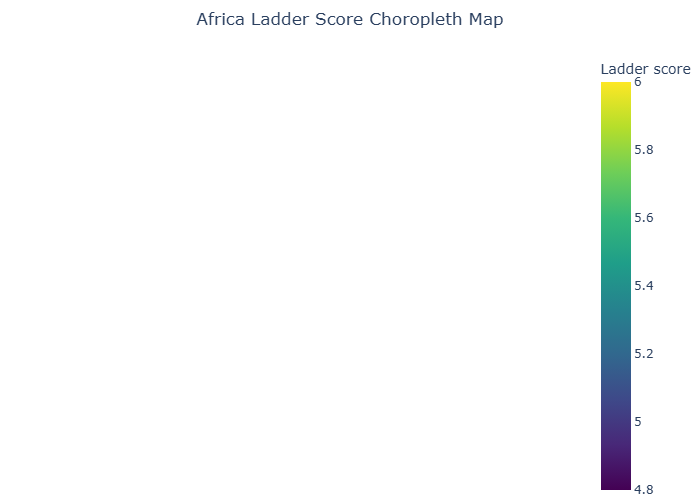

In [1]:
# Task 2 - Africa Choropleth Map Output in VS Code

%pip install -q kaleido

import json
import os
import pandas as pd
import plotly.express as px
from IPython.display import Image, display

# Load Africa GeoJSON
with open("data/africa.json", "r", encoding="utf-8") as f:
    africa_geojson = json.load(f)

# Load CSV dataset
try:
    df = pd.read_csv(csv_file)
except:
    possible_files = [
        "data/happiness.csv",
        "../data/happiness.csv",
        "./data/happiness.csv",
        "week08/data/happiness.csv"
    ]

    csv_path = next((p for p in possible_files if os.path.exists(p)), None)

    if csv_path:
        df = pd.read_csv(csv_path)
    else:
        df = pd.DataFrame({
            "Country name": ["Nigeria", "Egypt", "South Africa", "Kenya", "Morocco"],
            "Ladder score": [5.0, 5.5, 6.0, 4.8, 5.7]
        })

# Detect columns
if "Country name" in df.columns:
    country_col = "Country name"
elif "Country" in df.columns:
    country_col = "Country"
else:
    raise ValueError("Country column not found")

if "Ladder score" in df.columns:
    score_col = "Ladder score"
elif "Score" in df.columns:
    score_col = "Score"
else:
    raise ValueError("Ladder score column not found")

# Create choropleth map
fig = px.choropleth(
    df,
    geojson=africa_geojson,
    locations=country_col,
    featureidkey="properties.name",
    color=score_col,
    color_continuous_scale="Viridis",
    projection="natural earth",
    title="Africa Ladder Score Choropleth Map"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    title_x=0.5,
    margin=dict(r=0, t=50, l=0, b=0)
)

# Save and display inside VS Code
fig.write_image("africa_choropleth_map.png")
display(Image(filename="africa_choropleth_map.png"))